In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

### Create market making environment

In [4]:
import sys
sys.path.append("../") # This version of the notebook is in the subfolder "notebooks" of the repo

import gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad

from copy import deepcopy


from mbt_gym.agents.BaselineAgents import *
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *
import torch
#print(torch.cuda.is_available())
#print(torch.cuda.get_device_name())
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
seed = 42


### Parameters

In [5]:
max_inventory = 20

In [6]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 15
k = 1
fill_exponent = k
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [7]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)

psi value: 15.0


In [8]:
def get_env(num_trajectories:int = 1, fads_proportion:float=0.6, 
               psi:float = 15.0, phi:float = 15.0, eta:float = 10.0,
               gamma:float = 1.0,
               ) -> TradingEnvironment:
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModelPartialInformation(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [9]:
as_env = get_env(fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)

In [10]:
as_agent = ModifiedCarteaJaimungalMmAgent(env=as_env)
print(as_env.model_dynamics
      .midprice_model)


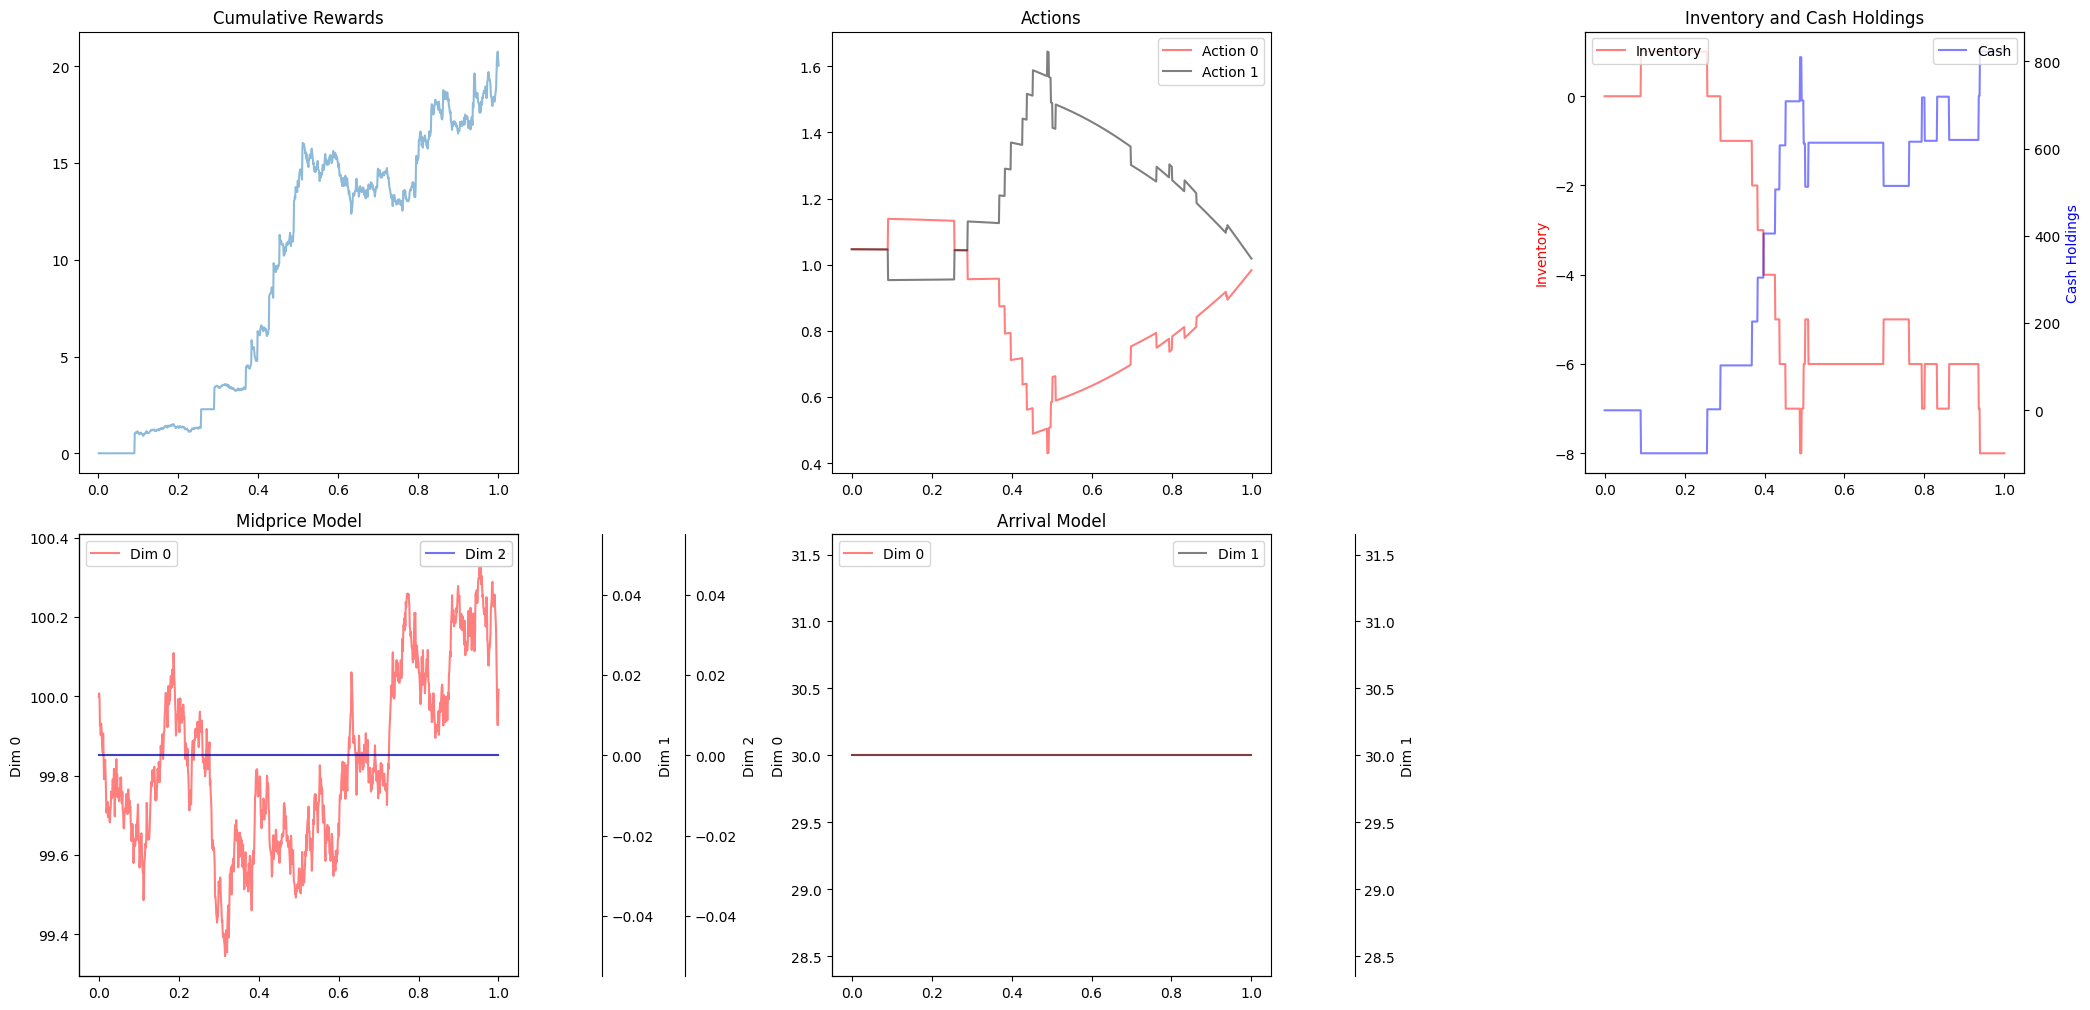

In [11]:
plot_trajectory_extended(as_env, as_agent)

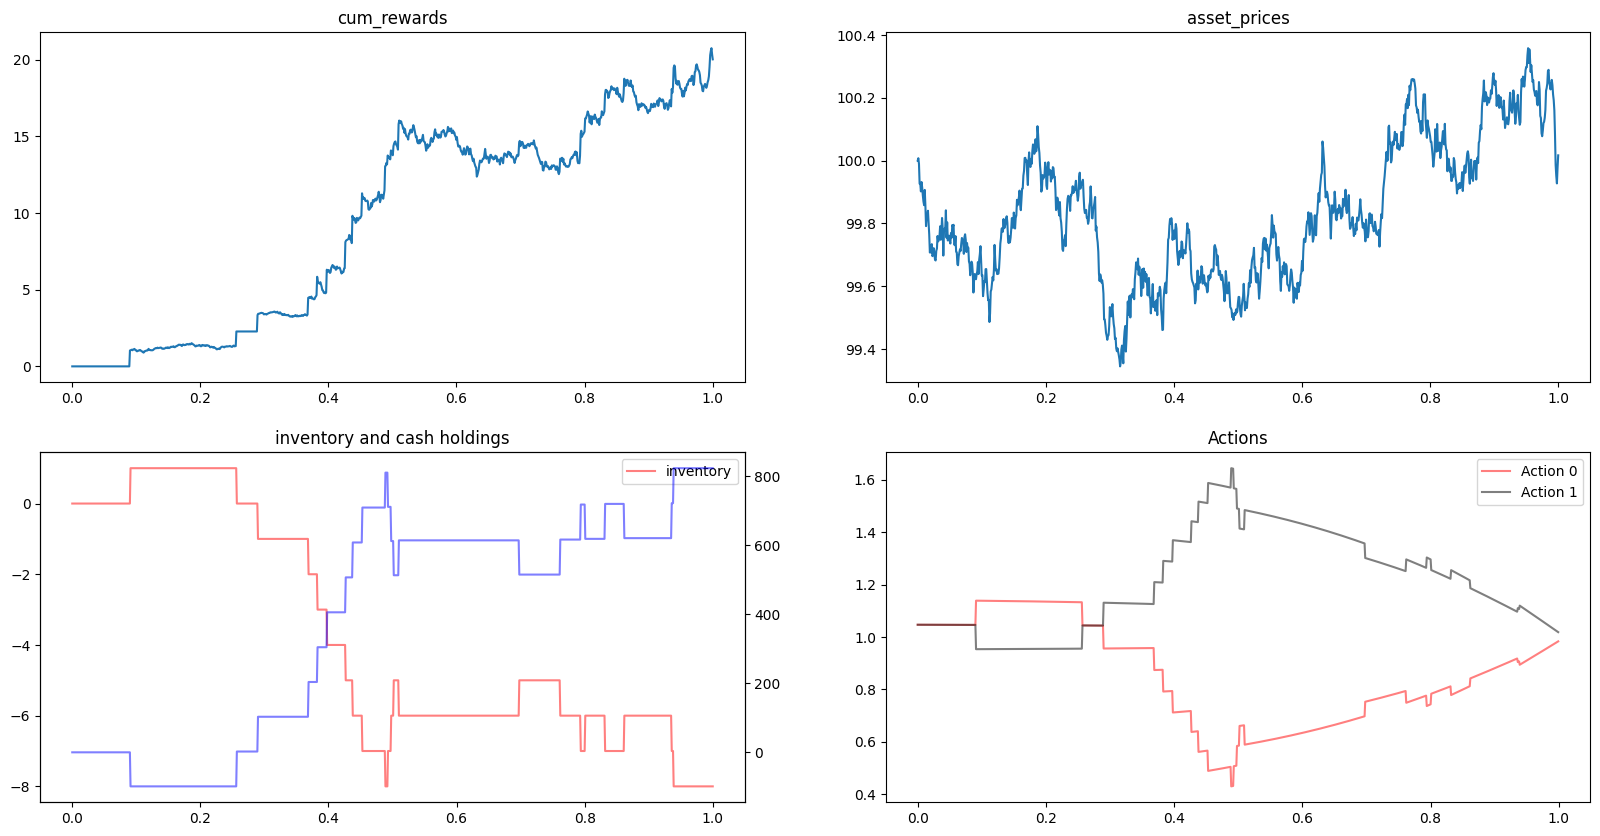

In [12]:
plot_trajectory(as_env, as_agent, seed = seed)

In [13]:
num_trajectories = 1000
vec_env = get_env(num_trajectories, fads_proportion=fads_proportion, psi=psi, phi=phi, eta=eta, gamma=gamma)
vec_as = ModifiedCarteaJaimungalMmAgent(env=vec_env)

print(vec_env.model_dynamics
      .midprice_model)

In [14]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [15]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [16]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065896,21.349544,4.952892,-0.08,3.07044


### Rinforncement Learning

In [66]:
num_trajectories = 1000
env = ReduceStateSizeWrapper(get_env(num_trajectories), [INVENTORY_INDEX,TIME_INDEX, ASSET_PRICE_INDEX])
#env = get_env(num_trajectories)
sb_env = StableBaselinesTradingEnvironment(trading_env=env)

In [67]:
# Monitor sb_env
sb_env = VecMonitor(sb_env)
# Add directory for tensorboard logging and best model
tensorboard_logdir = "./tensorboard/PPO-learning-CJ/"
best_model_path = "./SB_models/PPO-best-CJ"

In [68]:
policy_kwargs = dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])])
PPO_params = {"policy":'MlpPolicy', "env": sb_env, "verbose":1, 
              "policy_kwargs":policy_kwargs, 
              "tensorboard_log":tensorboard_logdir,
              "n_epochs":3,
              "batch_size": int(n_steps * num_trajectories / 10), 
              "n_steps": int(n_steps)}
callback_params = dict(eval_env=sb_env, n_eval_episodes = 2048, #200 before  (n_eval_episodes)
                       best_model_save_path = best_model_path, 
                       deterministic=True)

callback = EvalCallback(**callback_params)
model = PPO(**PPO_params, device="cpu")

Using cpu device


In [69]:
print(sb_env.observation_space)

Box([-20.          0.         -5.5999999], [ 20.           1.         105.59999847], (3,), float64)


In [70]:
model.learn(total_timesteps = 10_000_000)

Logging to ./tensorboard/PPO-learning-CJ/PPO_7
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1e+03    |
|    ep_rew_mean     | 5.69     |
| time/              |          |
|    fps             | 356325   |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 1000000  |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 1e+03        |
|    ep_rew_mean          | 5.65         |
| time/                   |              |
|    fps                  | 111890       |
|    iterations           | 2            |
|    time_elapsed         | 17           |
|    total_timesteps      | 2000000      |
| train/                  |              |
|    approx_kl            | 0.0031292767 |
|    clip_fraction        | 0.0119       |
|    clip_range           | 0.2          |
|    entropy_loss         | -2.84        |
|    explai

## Comparing the learnt policy to the optimal policy

In [71]:
from mbt_gym.agents.SbAgent import SbAgent

In [72]:
ppo_agent = SbAgent(model)

In [74]:
inventories = np.arange(-3,4,1)
bid_actions = []
ask_actions = []
for inventory in inventories:
    bid_action, ask_action = ppo_agent.get_action(np.array([[inventory,0.5,100]])).reshape(-1)
    bid_actions.append(bid_action)
    ask_actions.append(ask_action)    

In [ ]:
#ppo_agent.get_action(np.array([[inventory,0.5]]))

In [75]:
cj_agent = CarteaJaimungalMmAgent(env=get_env())

In [76]:
# Get the Cartea Jaimungal action
cj_bid_actions = []
cj_ask_actions = []
for inventory in inventories:
    bid_action, ask_action = cj_agent.get_action(np.array([[0,inventory,0.5]])).reshape(-1)
    cj_bid_actions.append(bid_action)
    cj_ask_actions.append(ask_action)

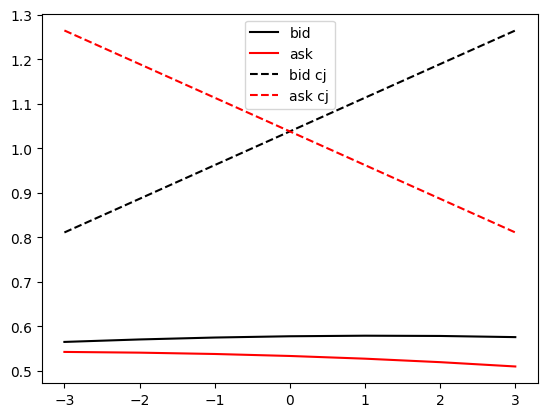

In [77]:
plt.plot(inventories, bid_actions, label = "bid", color = "k")
plt.plot(inventories, ask_actions, label = "ask", color = "r")
plt.plot(inventories, cj_bid_actions, label = "bid cj", color = "k", linestyle = "--")
plt.plot(inventories, cj_ask_actions, label = "ask cj", color = "r", linestyle = "--")
plt.legend()

extras


In [83]:
inventories = np.arange(-3, 4, 1)
prices = np.linspace(95, 105, 11)  # Example price range
bid_matrix = np.zeros((len(inventories), len(prices)))
ask_matrix = np.zeros((len(inventories), len(prices)))

for i, inventory in enumerate(inventories):
    for j, price in enumerate(prices):
        state = np.array([[inventory, 0.5, price]])
        bid_action, ask_action = ppo_agent.get_action(state).reshape(-1)
        bid_matrix[i, j] = bid_action
        ask_matrix[i, j] = ask_action

In [84]:
cj_agent = CarteaJaimungalMmAgent(env=get_env())

In [85]:
cj_bid_matrix = np.zeros((len(inventories), len(prices)))
cj_ask_matrix = np.zeros((len(inventories), len(prices)))

for i, inventory in enumerate(inventories):
    for j, price in enumerate(prices):
        state = np.array([[inventory, 0.5, price]])
        cj_bid_action, cj_ask_action = cj_agent.get_action(state).reshape(-1)
        cj_bid_matrix[i, j] = cj_bid_action
        cj_ask_matrix[i, j] = cj_ask_action

/opt/anaconda3/envs/mtb_gym_env/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:373: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUnifTraders_RL/../mbt_gym/agents/BaselineAgents.py:197: RuntimeWarning: invalid value encountered in matmul
  return np.matmul(expm(a_matrix * (self.terminal_time - current_time)), z_vector)


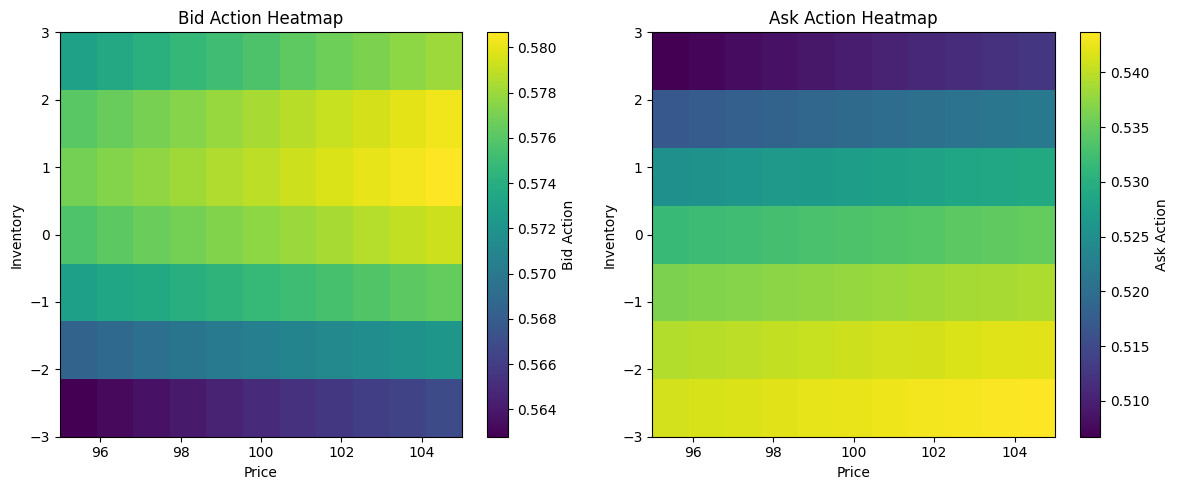

In [86]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(bid_matrix, aspect='auto', origin='lower', extent=[prices[0], prices[-1], inventories[0], inventories[-1]])
plt.colorbar(label="Bid Action")
plt.xlabel("Price")
plt.ylabel("Inventory")
plt.title("Bid Action Heatmap")

plt.subplot(1, 2, 2)
plt.imshow(ask_matrix, aspect='auto', origin='lower', extent=[prices[0], prices[-1], inventories[0], inventories[-1]])
plt.colorbar(label="Ask Action")
plt.xlabel("Price")
plt.ylabel("Inventory")
plt.title("Ask Action Heatmap")

plt.tight_layout()
plt.show()